# 05 — Build Pooled Dataset
Select the 87 common feature columns from each coin's feature file, add `coin_key`, and stack all 7 coins into a single modeling-ready dataset.

| # | Notebook | Reads → Writes |
|---|----------|----------------|
| 01 | Merge Raw Data | `raw/` → `merged/{coin}_5m_raw.parquet` |
| 02 | Clean & Label | `merged/` → `cleansed/{coin}_5m.parquet` |
| 03 | EDA | `cleansed/` |
| 03b | EDA — Downside Depegs | `cleansed/` |
| 04 | Feature Engineering | `cleansed/` → `features/{coin}_5m_features.parquet` |
| **▶ 05** | **Build Pooled Dataset** | `features/` → `features/pooled_5m.parquet` |
| 06 | Feature-Level EDA | `features/pooled_5m.parquet` |
| 07 | Feature Selection | `features/pooled_5m.parquet` → `features/selected_features.json` |
| 08 | Baseline Models | `features/pooled_5m.parquet` + `selected_features.json` → model results |
| 09 | Final Model (CatBoost) | + `selected_features.json` → `data/models/downside_depeg_catboost.cbm` + `downside_depeg_meta.json` |
| 10 | Threshold & Ops | `data/models/downside_depeg_meta.json` → threshold, alert metrics |
| 11 | LOEO Validation | `data/models/downside_depeg_meta.json` → leave-one-event-out results |
### Why pool after feature engineering?
Rolling windows (30-day z-scores, 4h sums, etc.) must operate within each coin's individual time series. Pooling first would contaminate a USDT rolling z-score with USDC values from a different date range. The correct order is: engineer features per-coin → pool for modeling.

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ── Environment detection ─────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Running in Google Colab — Drive mounted at /content/drive")
else:
    print("Running locally")

Running locally


In [2]:
DRIVE_PROJECT_PATH = "MyDrive/Capstone"   # ← Colab: path inside Google Drive
LOCAL_PROJECT_PATH = None                               # ← Local: set explicit path or None for auto-detect

if IN_COLAB:
    ROOT = Path("/content/drive") / DRIVE_PROJECT_PATH
elif LOCAL_PROJECT_PATH is not None:
    ROOT = Path(LOCAL_PROJECT_PATH)
else:
    _candidates = [Path.cwd()] + list(Path.cwd().parents)
    ROOT = next((p for p in _candidates if (p / "config" / "settings.py").exists()), None)
    if ROOT is None:
        raise FileNotFoundError(
            "Could not find project root (looked for config/settings.py). "
            "Set LOCAL_PROJECT_PATH above or run from within the project directory."
        )

os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

FEATURES_DIR = ROOT / "data" / "processed" / "features"
OUT_DIR      = FEATURES_DIR   # pooled_5m.parquet lives alongside the per-coin files

from config.settings import STABLECOINS
COINS = list(STABLECOINS.keys())

print(f"Project root:  {ROOT}")
print(f"Features dir:  {FEATURES_DIR}")
print(f"Coins:         {COINS}")

Project root:  /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global
Features dir:  /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global/data/processed/features
Coins:         ['usdt', 'usdc', 'dai', 'busd', 'ust', 'usde', 'rlusd']


## Column Definitions
76 common feature columns present in every coin's feature file, plus metadata and labels.

In [3]:
META_COLS  = ["date", "time", "coin", "peg", "coin_type", "coin_status"]

LABEL_COLS = [
    "depeg", "depeg_down",
    "depeg_next_5min",     "depeg_next_5min_down",
    "depeg_next_30min",    "depeg_next_30min_down",
    "depeg_next_1h",       "depeg_next_1h_down",
    "depeg_next_4h",       "depeg_next_4h_down",
    "depeg_next_24h",      "depeg_next_24h_down",
]

# Forward-looking label columns — rows with any NaN here are dropped
FORWARD_LABEL_COLS = [c for c in LABEL_COLS if c.startswith("depeg_next_")]

FEATURE_COLS = [
    # Raw price
    "coinapi_open", "coinapi_high", "coinapi_low", "coinapi_close", "coinapi_tick_count",
    # Market context (raw)
    "binance_btc_close", "binance_eth_close",
    "dxy", "vix", "t10y", "fedfunds", "fear_greed",
    # Price deviation (raw + engineered)
    "price_dev",
    "price_dev_mean_15min", "price_dev_std_15min", "price_dev_absmax_15min",
    "price_dev_mean_1h",    "price_dev_std_1h",    "price_dev_absmax_1h",
    "price_dev_mean_4h",    "price_dev_std_4h",    "price_dev_absmax_4h",
    "price_dev_diff1",
    "bars_above_01pct_15min", "bars_above_03pct_15min",
    "bars_above_01pct_1h",    "bars_above_03pct_1h",
    "bars_above_01pct_4h",    "bars_above_03pct_4h",
    "intrabar_range",
    # On-chain flows — z-scores at 1d, 7d, 30d windows
    "net_flow_sum_1h", "net_flow_sum_4h", "net_flow_sum_1d",
    "net_flow_zscore_1d", "net_flow_zscore_7d", "net_flow_zscore_30d",
    "mint_sum_1h", "burn_sum_1h", "mint_sum_4h", "burn_sum_4h",
    "burn_zscore_1d",  "burn_zscore_7d",  "burn_zscore_30d",
    "mint_zscore_1d",  "mint_zscore_7d",  "mint_zscore_30d",
    "mint_burn_ratio_1h", "mint_burn_ratio_4h", "mint_burn_ratio_1d",
    "net_flow_vol_1h", "net_flow_vol_4h",
    "net_flow_vol_zscore_1d", "net_flow_vol_zscore_7d", "net_flow_vol_zscore_30d",
    "burn_vol_1h", "burn_vol_4h",
    "burn_vol_zscore_1d", "burn_vol_zscore_7d", "burn_vol_zscore_30d",
    # Curve DEX pressure — z-scores at 1d, 7d, 30d windows
    "curve_net_sell_sum_15min", "curve_net_sell_sum_1h", "curve_net_sell_sum_4h",
    "curve_net_sell_zscore_1d", "curve_net_sell_zscore_7d", "curve_net_sell_zscore_30d",
    "curve_sell_buy_ratio_1h",
    "curve_net_sell_vol_1h", "curve_net_sell_vol_4h",
    "curve_net_sell_vol_zscore_1d", "curve_net_sell_vol_zscore_7d", "curve_net_sell_vol_zscore_30d",
    # Curve 3pool aggregate — systemic stress across all three major stablecoins
    "curve_3pool_total_sell_sum_1h", "curve_3pool_total_sell_sum_4h",
    "curve_3pool_total_sell_zscore_30d",
    # Market returns & volatility
    "btc_return_1h", "btc_return_4h", "eth_return_1h", "eth_return_4h",
    "btc_return_24h", "eth_return_24h",
    "btc_drawdown_accel", "eth_drawdown_accel",
    "btc_vol_4h", "btc_vol_1d",
    "vix_diff_1d", "vix_diff_1d_zscore_30d",
    # Return z-scores — scale-free market stress
    "btc_return_1h_zscore_30d", "btc_return_4h_zscore_30d",
    "eth_return_1h_zscore_30d", "eth_return_4h_zscore_30d",
    # Fear & Greed: level, z-score, and rate of change
    "fear_greed_level", "fear_greed_zscore_30d",
    "fear_greed_diff_1d", "fear_greed_diff_7d",
    # Temporal
    "hour_of_day", "day_of_week", "is_weekend", "is_us_market_hours",
    # Lags
    "lag1_price_dev",  "lag1_net_flow_usd",  "lag1_curve_net_sell",
    "lag3_price_dev",  "lag3_net_flow_usd",  "lag3_curve_net_sell",
    "lag6_price_dev",  "lag6_net_flow_usd",  "lag6_curve_net_sell",
    "lag12_price_dev", "lag12_net_flow_usd", "lag12_curve_net_sell",
    # Rate-of-change / acceleration — z-scores at 1d, 7d, 30d windows
    "price_dev_acc",
    "burn_acc_1h",     "burn_rate_ratio",
    "burn_acc_zscore_1d",  "burn_acc_zscore_7d",  "burn_acc_zscore_30d",
    "mint_acc_1h",     "mint_rate_ratio",
    "net_flow_acc_1h",
    "net_flow_acc_zscore_1d", "net_flow_acc_zscore_7d", "net_flow_acc_zscore_30d",
    "curve_acc_1h",    "curve_rate_ratio",
    "curve_acc_zscore_1d",  "curve_acc_zscore_7d",  "curve_acc_zscore_30d",
    # Systemic stress proxies — consistent across all coins (0.0 for self)
    "cross_usdt_price_dev", "cross_usdc_price_dev",
    # Structural — era flag for Curve DEX availability (0 = pre-Curve, 1 = post)
    "is_pre_curve",
]

ALL_COLS = META_COLS + LABEL_COLS + FEATURE_COLS

print(f"Meta cols:             {len(META_COLS)}")
print(f"Label cols:            {len(LABEL_COLS)}  ({len(FORWARD_LABEL_COLS)} forward-looking)")
print(f"Feature cols:          {len(FEATURE_COLS)}  (1d/7d/30d z-scores for all flow, Curve, and RoC)")
print(f"Total cols:            {len(ALL_COLS)}")

Meta cols:             6
Label cols:            12  (10 forward-looking)
Feature cols:          130  (1d/7d/30d z-scores for all flow, Curve, and RoC)
Total cols:            148


## 1. Stack All Coins
Read each coin's feature file, select common columns, drop tail rows where any forward-looking label is NaN (last 48 bars per coin due to the 4h horizon).

In [4]:
pieces = []
summary_rows = []

for coin_key in COINS:
    path = FEATURES_DIR / f"{coin_key}_5m_features.parquet"
    if not path.exists():
        print(f"[{coin_key.upper()}] ✗  not found — skipping")
        continue

    available = pd.read_parquet(path, columns=None).columns.tolist()
    read_cols = [c for c in ALL_COLS if c in available]
    missing   = [c for c in ALL_COLS if c not in available]

    df = pd.read_parquet(path, columns=read_cols)
    df.insert(0, "coin_key", coin_key)

    before = len(df)
    drop_subset = [c for c in FORWARD_LABEL_COLS if c in df.columns]
    df = df.dropna(subset=drop_subset)
    dropped = before - len(df)

    n_depeg  = int((df["depeg_next_1h"] == 1).sum())
    n_stable = int((df["depeg_next_1h"] == 0).sum())
    rate     = n_depeg / len(df) if len(df) > 0 else 0.0
    rate_down = df["depeg_next_1h_down"].mean() if "depeg_next_1h_down" in df.columns else float("nan")

    summary_rows.append({
        "coin":               coin_key.upper(),
        "rows":               len(df),
        "depeg_next_1h %":    round(rate * 100, 3),
        "depeg_next_1h_down %": round(rate_down * 100, 3),
        "dropped_tail":       dropped,
        "missing_cols":       len(missing),
    })

    pieces.append(df)
    print(f"[{coin_key.upper():5s}] {len(df):>9,} rows | "
          f"1h={rate:.2%}  1h_down={rate_down:.2%} | "
          f"dropped={dropped} | missing_cols={len(missing)}")
    if missing:
        print(f"          missing: {missing[:6]}{'…' if len(missing) > 6 else ''}")

pooled = pd.concat(pieces, axis=0).sort_index()

# Derive is_pre_curve — 1.0 before Curve 3pool deployment (Sep 2020), else 0.0
CURVE_CUTOFF = pd.Timestamp("2020-09-06", tz="UTC")
pooled["is_pre_curve"] = (pooled.index < CURVE_CUTOFF).astype(float)

print(f"\nPooled shape: {pooled.shape[0]:,} rows × {pooled.shape[1]} cols")

[USDT ]   897,647 rows | 1h=9.93%  1h_down=2.97% | dropped=289 | missing_cols=1
          missing: ['is_pre_curve']


[USDC ]   775,217 rows | 1h=5.93%  1h_down=0.26% | dropped=289 | missing_cols=1
          missing: ['is_pre_curve']


[DAI  ]   828,674 rows | 1h=11.90%  1h_down=2.23% | dropped=289 | missing_cols=1
          missing: ['is_pre_curve']


[BUSD ]   370,559 rows | 1h=0.38%  1h_down=0.00% | dropped=289 | missing_cols=1
          missing: ['is_pre_curve']
[UST  ]   153,672 rows | 1h=6.02%  1h_down=2.06% | dropped=289 | missing_cols=1
          missing: ['is_pre_curve']


[USDE ]   200,639 rows | 1h=0.10%  1h_down=0.10% | dropped=289 | missing_cols=1
          missing: ['is_pre_curve']
[RLUSD]    95,903 rows | 1h=0.00%  1h_down=0.00% | dropped=289 | missing_cols=1
          missing: ['is_pre_curve']



Pooled shape: 3,322,311 rows × 149 cols


## 2. Per-Coin Summary

In [5]:
summary_df = pd.DataFrame(summary_rows).set_index("coin")

totals = summary_df.sum(numeric_only=True)
totals["depeg_next_1h %"]      = round(sum(r["depeg_next_1h %"] * r["rows"] for r in summary_rows) / totals["rows"], 3)
totals["depeg_next_1h_down %"] = round(sum(r["depeg_next_1h_down %"] * r["rows"] for r in summary_rows) / totals["rows"], 3)
summary_df.loc["TOTAL"] = totals

display(summary_df.style
    .format({
        "rows":                 "{:,.0f}",
        "depeg_next_1h %":      "{:.3f}%",
        "depeg_next_1h_down %": "{:.3f}%",
        "dropped_tail":         "{:.0f}",
        "missing_cols":         "{:.0f}",
    })
    .highlight_max(subset=["depeg_next_1h %"], color="#ffe0e0")
    .highlight_min(subset=["depeg_next_1h %"], axis=0, color="#e0ffe0")
)

,rows,depeg_next_1h %,depeg_next_1h_down %,dropped_tail,missing_cols
coin,,,,,
USDT,"897,647",9.927%,2.972%,289,1
USDC,"775,217",5.930%,0.264%,289,1
DAI,"828,674",11.898%,2.231%,289,1
BUSD,"370,559",0.382%,0.000%,289,1
UST,"153,672",6.022%,2.062%,289,1
USDE,"200,639",0.103%,0.097%,289,1
RLUSD,"95,903",0.000%,0.000%,289,1
TOTAL,"3,322,311",7.361%,1.522%,2023,7


## 3. Class Balance

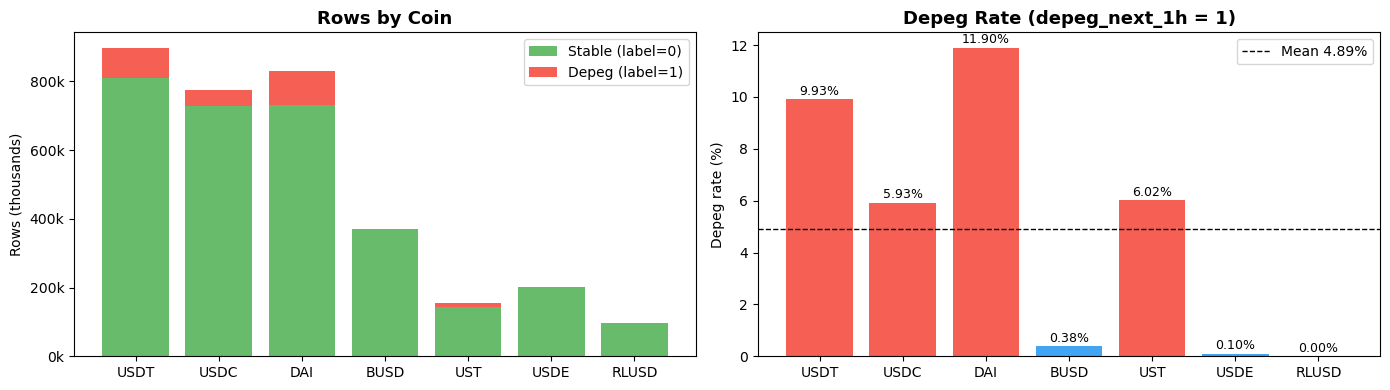

Overall: 244,552 depeg rows / 3,322,311 total = 7.361%
Class ratio (neg:pos): 13:1


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_df = summary_df.drop("TOTAL").copy()
plot_df["depeg_rows"]  = (plot_df["rows"] * plot_df["depeg_next_1h %"] / 100).round().astype(int)
plot_df["stable_rows"] = plot_df["rows"] - plot_df["depeg_rows"]

# ── Left: stacked bar — stable vs depeg rows per coin ────────────────────────
ax = axes[0]
stable = plot_df["stable_rows"] / 1e3
depeg  = plot_df["depeg_rows"]  / 1e3
ax.bar(plot_df.index, stable, label="Stable (label=0)", color="#4CAF50", alpha=0.85)
ax.bar(plot_df.index, depeg,  bottom=stable, label="Depeg (label=1)", color="#f44336", alpha=0.85)
ax.set_title("Rows by Coin", fontsize=13, fontweight="bold")
ax.set_ylabel("Rows (thousands)")
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}k"))

# ── Right: depeg rate per coin ────────────────────────────────────────────────
ax2 = axes[1]
rates = plot_df["depeg_next_1h %"]
colors = ["#f44336" if r > rates.mean() else "#2196F3" for r in rates]
bars = ax2.bar(rates.index, rates, color=colors, alpha=0.85)
ax2.axhline(rates.mean(), color="black", linestyle="--", linewidth=1, label=f"Mean {rates.mean():.2f}%")
for bar, val in zip(bars, rates):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f"{val:.2f}%", ha="center", va="bottom", fontsize=9)
ax2.set_title("Depeg Rate (depeg_next_1h = 1)", fontsize=13, fontweight="bold")
ax2.set_ylabel("Depeg rate (%)")
ax2.legend()

plt.tight_layout()
plt.show()

total_rows  = int(pooled.shape[0])
total_depeg = int((pooled["depeg_next_1h"] == 1).sum())
print(f"Overall: {total_depeg:,} depeg rows / {total_rows:,} total = {100*total_depeg/total_rows:.3f}%")
print(f"Class ratio (neg:pos): {(total_rows - total_depeg) / total_depeg:.0f}:1")

## 4. Feature Group Overview

In [7]:
feature_groups = {
    "Raw price (CoinAPI OHLCV)": [c for c in FEATURE_COLS if c.startswith("coinapi_")],
    "Market context": ["binance_btc_close", "binance_eth_close", "dxy", "vix", "t10y", "fedfunds", "fear_greed"],
    "Price deviation": [c for c in FEATURE_COLS if "price_dev" in c or "bars_above" in c or c == "intrabar_range"
                        and not c.startswith("cross_")],
    "On-chain flows": [c for c in FEATURE_COLS if "net_flow" in c or "mint" in c or "burn" in c],
    "Curve DEX pressure": [c for c in FEATURE_COLS if "curve" in c],
    "Market returns & vol": [c for c in FEATURE_COLS if "return" in c or "btc_vol" in c or "vix_diff" in c or "fear_greed_diff" in c],
    "Temporal": ["hour_of_day", "day_of_week", "is_weekend", "is_us_market_hours"],
    "Lags": [c for c in FEATURE_COLS if c.startswith("lag")],
    "Systemic stress": ["cross_usdt_price_dev", "cross_usdc_price_dev"],
    "Structural": ["is_pre_curve"],
}

print(f"{'Group':<35s} {'Count':>5}  Columns")
print("-" * 80)
total = 0
for group, cols in feature_groups.items():
    present = [c for c in cols if c in pooled.columns]
    print(f"{group:<35s} {len(present):>5}  {', '.join(present[:4])}{'…' if len(present) > 4 else ''}")
    total += len(present)
print("-" * 80)
print(f"{'Total':<35s} {total:>5}")

Group                               Count  Columns
--------------------------------------------------------------------------------
Raw price (CoinAPI OHLCV)               5  coinapi_open, coinapi_high, coinapi_low, coinapi_close…
Market context                          7  binance_btc_close, binance_eth_close, dxy, vix…
Price deviation                        25  price_dev, price_dev_mean_15min, price_dev_std_15min, price_dev_absmax_15min…
On-chain flows                         44  net_flow_sum_1h, net_flow_sum_4h, net_flow_sum_1d, net_flow_zscore_1d…
Curve DEX pressure                     25  curve_net_sell_sum_15min, curve_net_sell_sum_1h, curve_net_sell_sum_4h, curve_net_sell_zscore_1d…
Market returns & vol                   16  btc_return_1h, btc_return_4h, eth_return_1h, eth_return_4h…
Temporal                                4  hour_of_day, day_of_week, is_weekend, is_us_market_hours
Lags                                   12  lag1_price_dev, lag1_net_flow_usd, lag1_curve_net_sell, 

## 5. Sample Rows

In [8]:
preview_cols = ["coin_key", "depeg", "depeg_next_1h",
                "price_dev", "price_dev_mean_1h", "net_flow_sum_1h",
                "curve_net_sell_sum_1h", "btc_return_1h", "vix"]
present_preview = [c for c in preview_cols if c in pooled.columns]

print("— Stable rows (depeg_next_1h = 0) —")
display(pooled[pooled["depeg_next_1h"] == 0][present_preview].head(3))

print("\n— Depeg onset rows (depeg_next_1h = 1, depeg = 0) —")
onset = pooled[(pooled["depeg_next_1h"] == 1) & (pooled["depeg"] == 0)]
if len(onset) > 0:
    display(onset[present_preview].head(3))
else:
    print("  (no onset rows found — check label alignment)")

— Stable rows (depeg_next_1h = 0) —


,coin_key,depeg,depeg_next_1h,price_dev,price_dev_mean_1h,net_flow_sum_1h,curve_net_sell_sum_1h,btc_return_1h,vix
timestamp,,,,,,,,,
2017-08-17 04:05:00+00:00,usdt,NaN,0.0,0.0024,0.0024,0.0,0.0,0.0,15.55
2017-08-17 04:10:00+00:00,usdt,0.0,0.0,0.0024,0.0024,0.0,0.0,0.0,15.55
2017-08-17 04:15:00+00:00,usdt,0.0,0.0,0.0024,0.0024,0.0,0.0,0.0,15.55



— Depeg onset rows (depeg_next_1h = 1, depeg = 0) —


,coin_key,depeg,depeg_next_1h,price_dev,price_dev_mean_1h,net_flow_sum_1h,curve_net_sell_sum_1h,btc_return_1h,vix
timestamp,,,,,,,,,
2017-08-17 18:40:00+00:00,usdt,0.0,1.0,0.0023,0.001967,0.0,0.0,-0.020863,15.55
2017-08-17 18:45:00+00:00,usdt,0.0,1.0,0.0025,0.002008,0.0,0.0,-0.019928,15.55
2017-08-17 18:50:00+00:00,usdt,0.0,1.0,0.0025,0.002050,0.0,0.0,-0.012553,15.55


## 6. Save Pooled Dataset

In [9]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
out_path = OUT_DIR / "pooled_5m.parquet"

pooled.to_parquet(out_path)

total_rows      = len(pooled)
total_depeg     = int((pooled["depeg_next_1h"] == 1).sum())
total_depeg_down = int((pooled["depeg_next_1h_down"] == 1).sum()) if "depeg_next_1h_down" in pooled.columns else 0
size_mb = out_path.stat().st_size / 1e6

print(f"✓  Saved {out_path}")
print(f"   {total_rows:,} rows × {pooled.shape[1]} cols  ({size_mb:.1f} MB)")
print(f"   depeg_next_1h=1:      {total_depeg:,} ({100*total_depeg/total_rows:.3f}%)")
print(f"   depeg_next_1h_down=1: {total_depeg_down:,} ({100*total_depeg_down/total_rows:.3f}%)")
print(f"   coin distribution:")
for coin, cnt in pooled["coin_key"].value_counts().items():
    print(f"     {coin.upper():<6s} {cnt:>9,}  ({100*cnt/total_rows:.1f}%)")

✓  Saved /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global/data/processed/features/pooled_5m.parquet
   3,322,311 rows × 149 cols  (1702.3 MB)
   depeg_next_1h=1:      244,552 (7.361%)
   depeg_next_1h_down=1: 50,578 (1.522%)
   coin distribution:
     USDT     897,647  (27.0%)
     DAI      828,674  (24.9%)
     USDC     775,217  (23.3%)
     BUSD     370,559  (11.2%)
     USDE     200,639  (6.0%)
     UST      153,672  (4.6%)
     RLUSD     95,903  (2.9%)


## 7. Next Step
Run `06_eda_features.ipynb` for modeling-level EDA — feature distributions at depeg onset vs stable bars, correlation analysis, and feature group discriminative power — using `pooled_5m.parquet`.